Setup

In [23]:
%pip install -q seaborn mlflow dagshub "timesfm[torch,xreg]"

import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)

CODE_PATHS = ["preprocessing.py", "evaluation.py", "models.py"]

ARCH = "TimesFM"

In [25]:
import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

MLflow experiment: TimesFM_Training


In [26]:
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)

train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


In [27]:
features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")

🏃 View run TimesFM_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/2c6e0d4e141349cf88facc16c4a2f2c5
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
cleaning done


In [28]:
train_weeks = np.sort(train_raw.Date.unique())
val_start_target = TEST_START - pd.DateOffset(years=1)
val_end_target   = TEST_END   - pd.DateOffset(years=1)
val_start = pd.Timestamp(train_weeks[np.argmin(np.abs(train_weeks - np.datetime64(val_start_target)))])
val_end   = pd.Timestamp(train_weeks[np.argmin(np.abs(train_weeks - np.datetime64(val_end_target)))])

train_part = train_raw[train_raw.Date < val_start].copy()
val_part   = train_raw[(train_raw.Date >= val_start) & (train_raw.Date <= val_end)].copy()

val_dates  = pd.date_range(val_start, val_end, freq="7D")
test_dates = pd.date_range(TEST_START, TEST_END, freq="7D")

print(f"train_part: {len(train_part)} rows (... {train_part.Date.max().date()})")
print(f"val_part  : {len(val_part)} rows ({val_part.Date.min().date()} ... {val_part.Date.max().date()})")
print(f"val weeks : {len(val_dates)} (should equal HORIZON={HORIZON})")
print("holiday weeks in val:", val_part.groupby('Date').IsHoliday.first().sum())

train_part: 267184 rows (... 2011-10-28)
val_part  : 115856 rows (2011-11-04 ... 2012-07-27)
val weeks : 39 (should equal HORIZON=39)
holiday weeks in val: 3


In [29]:
shares_woy, shares_ov = prep.build_shares(train_part)
GLOBAL_MED = float(train_part.Weekly_Sales.median())
totals_tr = prep.store_totals(train_part)
totals_full = prep.store_totals(train_raw)
store_types = stores_raw.set_index("Store")["Type"].to_dict()
print("store totals:", totals_tr.shape, "| val weeks:", len(val_dates))

store totals: (91, 45) | val weeks: 39


TimesFM setup: load the pretrained checkpoint, no training loop

In [30]:
import timesfm

CHECKPOINT = "google/timesfm-2.5-200m-pytorch"

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(CHECKPOINT)

MAX_CTX = len(totals_tr.index)
model.compile(timesfm.ForecastConfig(
    max_context=MAX_CTX, max_horizon=HORIZON,
    normalize_inputs=True, return_backcast=False,
))
print(f"loaded {CHECKPOINT} | max_context={MAX_CTX} | max_horizon={HORIZON}")

loaded google/timesfm-2.5-200m-pytorch | max_context=91 | max_horizon=39


Zero-shot store-level forecasts

In [31]:
def zero_shot_store_forecast(model, totals, fc_dates, context=None):
    horizon = len(fc_dates)
    inputs = [totals[s].values[-context:].astype(np.float32) if context
              else totals[s].values.astype(np.float32)
              for s in totals.columns]
    point_fc, _ = model.forecast(horizon=horizon, inputs=inputs)
    preds = {s: np.asarray(point_fc[i]).ravel()[-horizon:]
             for i, s in enumerate(totals.columns)}
    long = (pd.DataFrame(preds, index=fc_dates).rename_axis("Date")
            .reset_index().melt("Date", var_name="Store", value_name="store_pred"))
    long["Store"] = long.Store.astype(int)
    return long

In [32]:
ZERO_SHOT_CONFIGS = {
    "zero_shot_ctx52": dict(context=52),
    "zero_shot_full":  dict(context=None),
}

results, store_fcs = {}, {}
for name, kw in ZERO_SHOT_CONFIGS.items():
    t0 = time.time()
    fc_long = zero_shot_store_forecast(model, totals_tr, val_dates, **kw)
    pred = prep.disaggregate(val_part[["Store", "Dept", "Date"]], fc_long,
                             shares_woy, shares_ov, GLOBAL_MED)
    s = wmae(val_part.Weekly_Sales.values, pred, val_part.IsHoliday.values)
    results[name], store_fcs[name] = s, fc_long
    with mlflow.start_run(run_name=f"{ARCH}_StoreLevel_{name}"):
        mlflow.log_params({"config": name, "checkpoint": CHECKPOINT,
                           "context": kw["context"] or "full", "covariates": "none"})
        mlflow.log_metric("val_wmae", s)
        mlflow.log_metric("fit_seconds", time.time() - t0)
    print(f"{name:20s} val WMAE = {s:10,.1f}   ({time.time()-t0:.0f}s)")

🏃 View run TimesFM_StoreLevel_zero_shot_ctx52 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/651a9c68e5bd4ade9ac2b95b4a4cdec8
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
zero_shot_ctx52      val WMAE =    2,833.8   (26s)
🏃 View run TimesFM_StoreLevel_zero_shot_full at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/6db7db2528ab41e7892934c6299f85a5
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
zero_shot_full       val WMAE =    2,658.8   (26s)


XReg: holiday-aware forecasts

In [33]:
model.compile(timesfm.ForecastConfig(
    max_context=MAX_CTX, max_horizon=HORIZON,
    normalize_inputs=True, return_backcast=True,
))

hol_hist = (train_part.groupby("Date").IsHoliday.first()
            .reindex(totals_tr.index).fillna(False).astype(np.float32))
hol_fut  = (val_part.groupby("Date").IsHoliday.first()
            .reindex(val_dates).fillna(False).astype(np.float32))

def xreg_store_forecast(model, totals, fc_dates, hol_hist, hol_fut,
                        static_type=False, ridge=1e-3):
    horizon = len(fc_dates)
    inputs = [totals[s].values.astype(np.float32) for s in totals.columns]
    hol_combined = np.concatenate([hol_hist.values, hol_fut.values])
    dyn_num = {"IsHoliday": [hol_combined for _ in totals.columns]}
    static_cat = ({"StoreType": [str(store_types.get(s, "unknown")) for s in totals.columns]}
                  if static_type else None)
    point_out, _xreg_out = model.forecast_with_covariates(
        inputs=inputs,
        dynamic_numerical_covariates=dyn_num,
        static_categorical_covariates=static_cat,
        xreg_mode="xreg + timesfm",
        ridge=ridge,
        normalize_xreg_target_per_input=True,
    )
    preds = {s: np.asarray(point_out[i]).ravel()[-horizon:]
             for i, s in enumerate(totals.columns)}
    long = (pd.DataFrame(preds, index=fc_dates).rename_axis("Date")
            .reset_index().melt("Date", var_name="Store", value_name="store_pred"))
    long["Store"] = long.Store.astype(int)
    return long

XREG_CONFIGS = {
    "xreg_holiday":      dict(static_type=False),
    "xreg_holiday_type": dict(static_type=True),
}

for name, kw in XREG_CONFIGS.items():
    t0 = time.time()
    fc_long = xreg_store_forecast(model, totals_tr, val_dates, hol_hist, hol_fut, **kw)
    pred = prep.disaggregate(val_part[["Store", "Dept", "Date"]], fc_long,
                             shares_woy, shares_ov, GLOBAL_MED)
    s = wmae(val_part.Weekly_Sales.values, pred, val_part.IsHoliday.values)
    results[name], store_fcs[name] = s, fc_long
    with mlflow.start_run(run_name=f"{ARCH}_StoreLevel_{name}"):
        mlflow.log_params({"config": name, "checkpoint": CHECKPOINT,
                           "covariates": "IsHoliday" + ("+StoreType" if kw["static_type"] else ""),
                           "xreg_mode": "xreg + timesfm"})
        mlflow.log_metric("val_wmae", s)
        mlflow.log_metric("fit_seconds", time.time() - t0)
    print(f"{name:20s} val WMAE = {s:10,.1f}   ({time.time()-t0:.0f}s)")

res_df = pd.DataFrame({"val_wmae": results}).sort_values("val_wmae")
print("\n", res_df)
best_name = min(results, key=results.get)
best_is_xreg = best_name in XREG_CONFIGS
best_kw = (XREG_CONFIGS if best_is_xreg else ZERO_SHOT_CONFIGS)[best_name]
best_val_pred = prep.disaggregate(val_part[["Store", "Dept", "Date"]], store_fcs[best_name],
                                  shares_woy, shares_ov, GLOBAL_MED)
print("\nbest config:", best_name, "| val WMAE:", round(results[best_name], 1))

🏃 View run TimesFM_StoreLevel_xreg_holiday at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/a4d9558488b64c5e8916cb70fe905387
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
xreg_holiday         val WMAE =    2,581.9   (23s)
🏃 View run TimesFM_StoreLevel_xreg_holiday_type at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/ed9f74e7f5e84cf983507b1e54f2cc4a
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
xreg_holiday_type    val WMAE =    2,581.9   (26s)

                       val_wmae
xreg_holiday       2581.914507
xreg_holiday_type  2581.915489
zero_shot_full     2658.808574
zero_shot_ctx52    2833.802408

best config: xreg_holiday | val WMAE: 2581.9


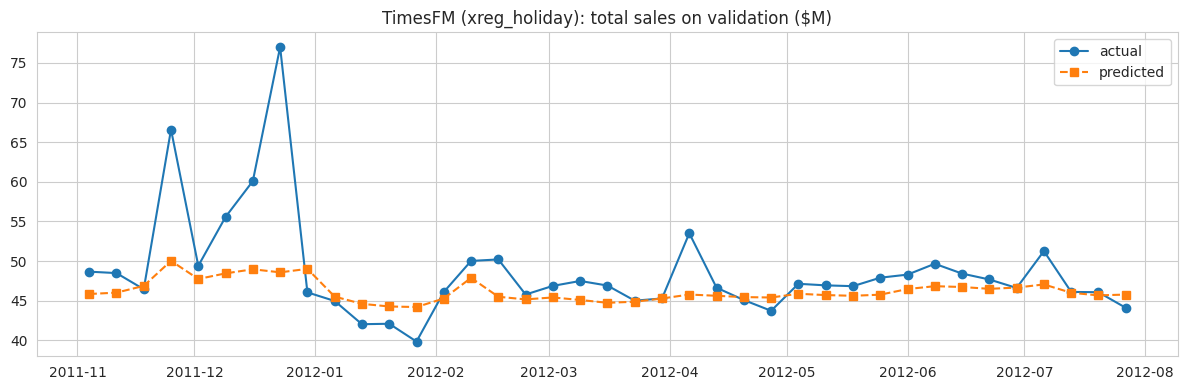

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
a = val_part.groupby("Date").Weekly_Sales.sum() / 1e6
p = pd.Series(best_val_pred, index=val_part.index).groupby(val_part.Date).sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="predicted")
ax.set_title(f"{ARCH} ({best_name}): total sales on validation ($M)")
ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_total.png", dpi=120); plt.show()

Final pipeline + submission

In [35]:
from models import StoreShareForecastPipeline

REGISTER_AS_BEST = False

shares_woy_full, shares_ov_full = prep.build_shares(train_raw)
GLOBAL_MED_FULL = float(train_raw.Weekly_Sales.median())

if best_is_xreg:
    hol_hist_full = (train_raw.groupby("Date").IsHoliday.first()
                     .reindex(totals_full.index).fillna(False).astype(np.float32))
    hol_fut_full  = (features_clean.groupby("Date").IsHoliday.first()
                     .reindex(test_dates).fillna(False).astype(np.float32))
    store_fc_full = xreg_store_forecast(model, totals_full, test_dates,
                                        hol_hist_full, hol_fut_full, **best_kw)
else:
    store_fc_full = zero_shot_store_forecast(model, totals_full, test_dates, **best_kw)

wrapper = StoreShareForecastPipeline(store_fc_full, shares_woy_full,
                                     shares_ov_full, GLOBAL_MED_FULL)
test_pred = wrapper.predict(None, test_raw[["Store", "Dept", "Date"]])
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({"config": best_name, "strategy": "store-level + dept-share",
                       "checkpoint": CHECKPOINT})
    mlflow.log_metric("val_wmae", results[best_name])
    if os.path.exists(f"pictures/{ARCH.lower()}_val_total.png"):
        mlflow.log_artifact(f"pictures/{ARCH.lower()}_val_total.png")
    mlflow.pyfunc.log_model(
        "model", python_model=wrapper, code_paths=CODE_PATHS,
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)

sub = ev.make_submission(test_raw, test_pred, f"submission_{ARCH}.csv")
print("saved:", f"submission_{ARCH}.csv")

2026/07/10 23:32:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 23:32:34 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/10 23:32:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run TimesFM_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6/runs/a128e6249e0e4de89baba13004739950
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/6
pipeline logged, run_id = a128e6249e0e4de89baba13004739950
saved: submission_TimesFM.csv
